# ***Ⅳ. 예측과 최적화***
# ***5. 경사하강법***

## ***손실함수의 최솟값 찾기***
- 먼저 두 점이 움직이는 방향과 손실함수의 미분계수의 부호는 어떤 의미가 있을까요?

### ***1. 이동 방향의 결정: 미분계수의 부호***
- 미분계수가 양수일 때
    - 아래 코드를 실행하여 나오는 그림에서 점 A를 점 P로 이동하려면 a축의 음의 방향으로 움직여야 합니다
    - 이때 점 A에서의 미분계수의 부호는 양수입니다
    - 따라서 **미분계수가 양수인 경우에는 a축의 음의 방향으로 이동해야 합니다**
- 미분계수가 음수일 때
    - 아래 코드를 실행하여 나오는 그림에서 점 B를 점 P로 이동하려면 a축의 양의 방향으로 움직여야 합니다
    - 이때 점 B에서의 미분계수의 부호는 음수입니다
    - 따라서 **미분계수가 음수인 경우에는 a축의 양의 방향으로 이동해야 합니다**
- 즉, 손실함수의 최솟값을 찾기 위해서는 **미분계수의 부호와 반대 방향으로 이동해야 합니다**

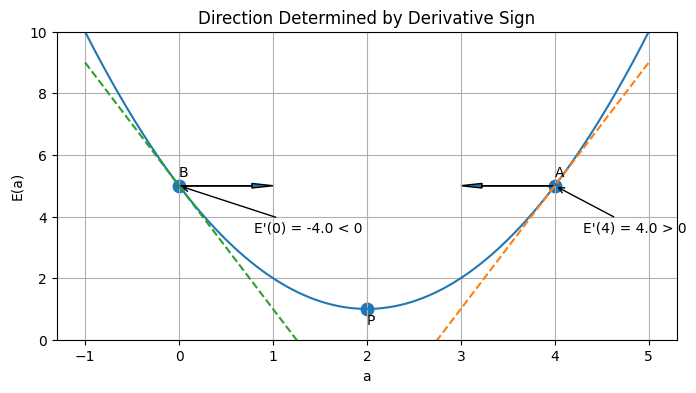

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 완전제곱식으로 표현한 이차함수 입니다
def E(a):
    return (a - 2)**2 + 1


# 도함수
def dE(a):
    return 2*(a - 2)

x = np.linspace(-1, 5, 400)

A = 4
B = 0
P = 2

plt.figure(figsize=(8,4))
plt.plot(x, E(x))

plt.scatter([A, B, P],
            [E(A), E(B), E(P)],
            s=80)

plt.text(A, E(A)+0.3, "A")
plt.text(B, E(B)+0.3, "B")
plt.text(P, E(P)-0.5, "P")

# 접선
tangent_A = E(A) + dE(A) * (x - A)
tangent_B = E(B) + dE(B) * (x - B)

plt.plot(x, tangent_A, '--', label=f"Tangent at A (slope={dE(A):.0f})")
plt.plot(x, tangent_B, '--', label=f"Tangent at B (slope={dE(B):.0f})")
# 이동 방향
plt.arrow(A, E(A), -1, 0,
          head_width=0.15,
          length_includes_head=True)

plt.arrow(B, E(B), 1, 0,
          head_width=0.15,
          length_includes_head=True)

# 미분계수 표시
plt.annotate(
    f"E'({A}) = {dE(A):.1f} > 0",
    xy=(A, E(A)),
    xytext=(4.3, 3.5),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f"E'({B}) = {dE(B):.1f} < 0",
    xy=(B, E(B)),
    xytext=(0.8, 3.5),
    arrowprops=dict(arrowstyle="->")
)

plt.ylim(0, 10)

plt.title("Direction Determined by Derivative Sign")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.grid(True)

plt.show()

## ***2. 이동 거리의 결정: 학습률***
- 손실함수의 y 값이 최소가 되어야 오차가 적은 추세선이 됩니다
- 이차곡선의 극소점으로 이동하는 것입니다
- 그러면 임의의 y 지점에서 출발하여 y 값이 최소인 지점으로 이동하려면 그 점에서의 미분계수 부호와 반대 방향으로 이동해야 합니다
- 그렇다면 얼마만큼 이동해야 할까요?

### ***학습률이 너무 작은 경우***
- 점 A가 조금씩 이동하면 손실함수의 최솟값이 되는 점 P에 도달하기까지 많은 반복이 필요합니다

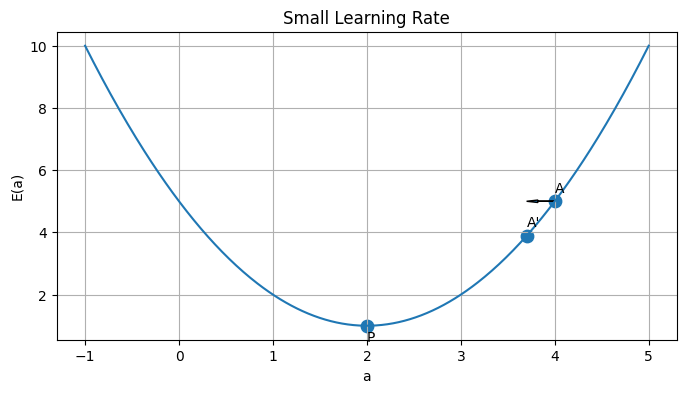

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def E(a):
    return (a - 2)**2 + 1

x = np.linspace(-1, 5, 400)

A = 4
A_small = 3.7
P = 2

plt.figure(figsize=(8,4))
plt.plot(x, E(x))

plt.scatter([A, A_small, P],
            [E(A), E(A_small), E(P)],
            s=80)

plt.text(A, E(A)+0.3, "A")
plt.text(A_small, E(A_small)+0.3, "A'")
plt.text(P, E(P)-0.5, "P")

plt.arrow(A, E(A), -0.3, 0,
          head_width=0.08, length_includes_head=True)

plt.title("Small Learning Rate")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.grid(True)
plt.show()

### ***학습률이 너무 큰 경우***
- 점 A가 너무 크게 이동하면 최솟값을 지나쳐 버릴 수 있으며, 오히려 최솟값에 가까워지지 못할 수 있습니다

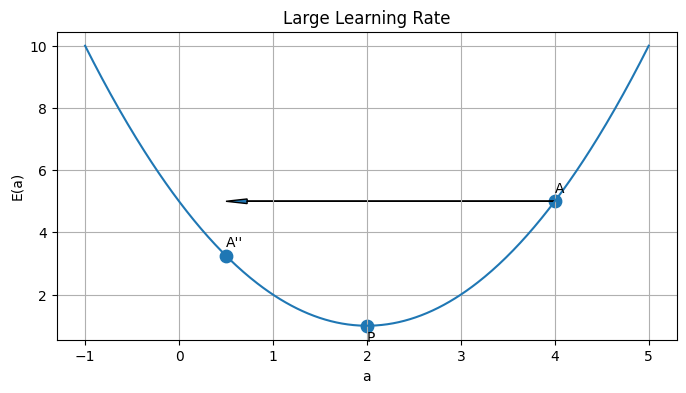

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def E(a):
    return (a - 2)**2 + 1

x = np.linspace(-1, 5, 400)

A = 4
A_large = 0.5
P = 2

plt.figure(figsize=(8,4))
plt.plot(x, E(x))

plt.scatter([A, A_large, P],
            [E(A), E(A_large), E(P)],
            s=80)

plt.text(A, E(A)+0.3, "A")
plt.text(A_large, E(A_large)+0.3, "A''")
plt.text(P, E(P)-0.5, "P")

plt.arrow(A, E(A), -3.5, 0,
          head_width=0.15, length_includes_head=True)

plt.title("Large Learning Rate")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.grid(True)
plt.show()

### ***학습률***
- 따라서 적절한 이동 폭을 결정하는 변수가 필요한데, 이를 **학습률(Learning Rate)** 이라고 합니다
- 아래 코드를 실행하여 학습률에 따른 변화를 확인해봅니다

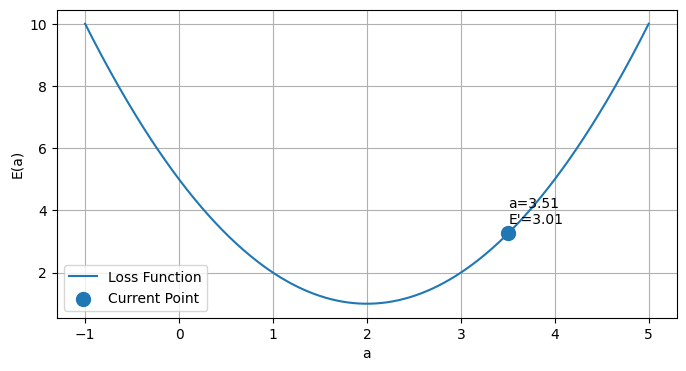

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def E(a):
    return (a - 2)**2 + 1

def dE(a):
    return 2*(a - 2)

x = np.linspace(-1, 5, 400)

a = 4          # 시작점을 바꾸면서 확인해봅니다
lr = 0.01      # 학습률

for epoch in range(15):

    clear_output(wait=True)

    plt.figure(figsize=(8,4))

    plt.plot(x, E(x), label="Loss Function")

    plt.scatter(a, E(a), s=100, label="Current Point")

    grad = dE(a)

    plt.text(
        a,
        E(a)+0.3,
        f"a={a:.2f}\nE'={grad:.2f}"
    )

    plt.legend()
    plt.grid(True)
    plt.xlabel("a")
    plt.ylabel("E(a)")

    plt.show()

    # 경사하강법
    a = a - lr * grad

    time.sleep(0.5)

## ***3. 경사하강법***
- a 값에 대한 미분계수를 구합니다
- 학습률만큼 변화시켜 새로운 a를 구합니다
- ***$(a, E(a))$ 가 최소가 되는 지점 P에 충분히 가까워질 때까지 반복합니다***

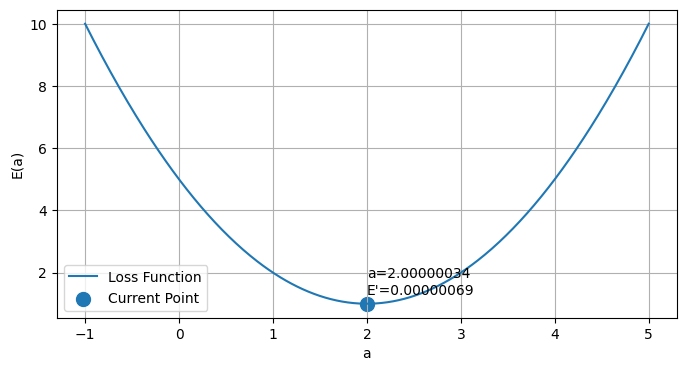

18회 반복


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def E(a):
    return (a - 2)**2 + 1

def dE(a):
    return 2*(a - 2)

x = np.linspace(-1, 5, 400)

a = 4           # 시작점을 바꾸면서 확인해봅니다
lr = 0.3        # 학습률

tolerance = 0.000001 # 허용 오차
grad = 999999999

iter = 0

# 기울기가 최소에 근접하면 종료합니다
while abs(grad) > tolerance:

    clear_output(wait=True)

    plt.figure(figsize=(8,4))

    plt.plot(x, E(x), label="Loss Function")

    plt.scatter(a, E(a), s=100, label="Current Point")

    grad = dE(a)

    plt.text(
        a,
        E(a)+0.3,
        f"a={a:.8f}\nE'={grad:.8f}"
    )

    plt.legend()
    plt.grid(True)
    plt.xlabel("a")
    plt.ylabel("E(a)")

    plt.show()

    # 경사하강법
    a = a - lr * grad

    time.sleep(0.5)

    iter += 1

print(f'{iter}회 반복')

### ***경사하강법에서 적절한 학습률***
- 위에서 사용한 손실함수와 다른 손실함수를 사용해봅니다
- 학습률 0.6에서 손실이 발산하는 것을 볼 수 있습니다
- 학습률을 바꾸면서 반복 횟수가 가장 적은 경우를 찾아봅니다

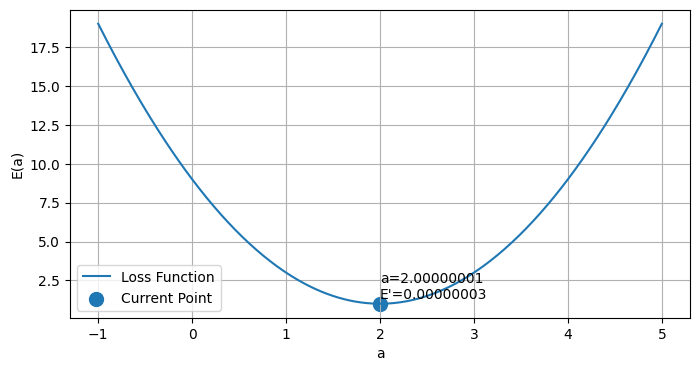

13회 반복


In [96]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def E(a):
    return 2*a**2 - 8*a + 9

def dE(a):
    return 4*a - 8

x = np.linspace(-1, 5, 400)

a = 4           # 시작점을 바꾸면서 확인해봅니다
lr = 0.2        # 학습률을 줄여보면서 확인해봅니다

tolerance = 0.0000001 # 허용 오차
grad = 999999999

iter = 0

# 기울기가 최소에 근접하면 종료합니다
while abs(grad) > tolerance:

    clear_output(wait=True)

    plt.figure(figsize=(8,4))

    plt.plot(x, E(x), label="Loss Function")

    plt.scatter(a, E(a), s=100, label="Current Point")

    grad = dE(a)

    plt.text(
        a,
        E(a)+0.3,
        f"a={a:.8f}\nE'={grad:.8f}"
    )

    plt.legend()
    plt.grid(True)
    plt.xlabel("a")
    plt.ylabel("E(a)")

    plt.show()

    # 경사하강법
    a = a - lr * grad

    time.sleep(0.5)

    iter += 1

print(f'{iter}회 반복')

### ***반복하면서 변하는 학습률***
- 학습을 반복하면서 학습률을 각각 다르게 적용해볼 수도 있습니다

In [98]:
lrs = [0.3]*4 + [0.2]*10
lrs

[0.3, 0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]

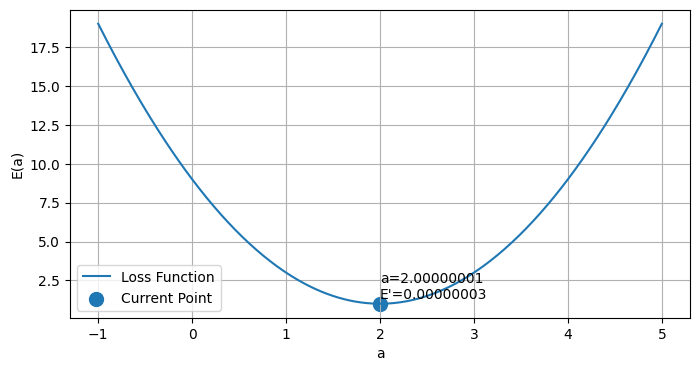

13회 반복


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def E(a):
    return 2*a**2 - 8*a + 9

def dE(a):
    return 4*a - 8

x = np.linspace(-1, 5, 400)

a = 4           # 시작점을 바꾸면서 확인해봅니다
lr = 0.2        # 학습률을 줄여보면서 확인해봅니다

tolerance = 0.0000001 # 허용 오차
grad = 999999999

iter = 0

# 기울기가 최소에 근접하면 종료합니다
while abs(grad) > tolerance:
    lr = lrs[iter]
    print(f'현재 학습률={lr}')

    clear_output(wait=True)

    plt.figure(figsize=(8,4))

    plt.plot(x, E(x), label="Loss Function")

    plt.scatter(a, E(a), s=100, label="Current Point")

    grad = dE(a)

    plt.text(
        a,
        E(a)+0.3,
        f"a={a:.8f}\nE'={grad:.8f}"
    )

    plt.legend()
    plt.grid(True)
    plt.xlabel("a")
    plt.ylabel("E(a)")

    plt.show()

    # 경사하강법
    a = a - lr * grad

    time.sleep(0.5)

    iter += 1

print(f'{iter}회 반복')

### ***손실함수 전개하기***
- 아래 코드를 사용하면 손실함수를 작성 후 쉽게 전개결과를 얻을 수 있습니다

In [1]:
import sympy as sp

x, y = sp.symbols('x y')

expr = (62 - 5*x)**2  + (120 - 6*x)**2 + (276 - 7*x)**2 + (465 - 8*x)**2 + (636 - 9*x)**2 + (737 - 10*x)**2
sp.expand(expr)

355*x**2 - 39552*x + 1258310